# 02 — CMIP6 Multi-Model Climate Projections

**The thesis of this notebook**: a single climate model's line is an opinion; the multi-model *range* is the finding.

> **CMIP6** — the Coupled Model Intercomparison Project, phase 6: independent research groups run their climate models over agreed scenarios, so that the models can be compared. Open-Meteo serves high-resolution (HighResMIP) runs on native grids of ~20–50 km, statistically downscaled to ~10 km before delivery.

> **Downscaling** — mapping coarse model output onto a finer grid. Open-Meteo does it statistically, using ERA5-Land as the fine-scale reference, not by running the models at a higher resolution.

> **Projection ≠ forecast** — a forecast starts from today's observed atmosphere and predicts specific weather. A projection is driven by a *scenario* and makes no claim about any particular year. All projections here follow a single high-emission pathway (RCP8.5-like); Open-Meteo offers no scenario choice, and reports that scenarios differ little before 2050.

**Setup**

- Endpoint: Climate API, 2015–2050.
- Locations, the same two as [notebook 01](01-open-meteo-exploration.ipynb): Pampa, Argentina (-34.6, -58.4) and Midwest, USA (41.9, -89.1).
- Models: `EC_Earth3P_HR` (EC-Earth consortium, EU), `MRI_AGCM3_2_S` (Meteorological Research Institute, Japan), `FGOALS_f3_H` (Chinese Academy of Sciences).

**How to read**: each section goes from a Question to an Expectation, a Result and a Conclusion. The canonical quality record is [`docs/data-quality-report.md`](../docs/data-quality-report.md).

**Data**: Climate data by [Open-Meteo.com](https://open-meteo.com/) (CC BY 4.0). We acknowledge the World Climate Research Programme's CMIP6 and the three modelling groups listed above ([Terms of Use](https://pcmdi.llnl.gov/CMIP6/TermsOfUse)). Contains modified Copernicus Climate Change Service information 2026. Full attribution in the [README](../README.md#data-licensing--attribution).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from pretaverdi.analysis import (
    annual_mean_temperature,
    annual_precipitation,
    decadal_change,
    hindcast_annual,
    inter_model_spread,
    mean_levels,
    nan_share,
)
from pretaverdi.client import get_climate_projections
from pretaverdi.plots import plot_bias, plot_model_spread
from pretaverdi.variables import LOCATIONS

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Fetch Projections — Three Models, One Request

**Question**

What does one multi-model request return?

**Request**

- 36 years of daily data (2015–2050) for three models, in one call per site.
- The API returns one message per model; the client joins them into `(variable, model)` columns and checks the labels.

*Reproducibility*: large requests can hit the free tier's per-minute limit ("Minutely API request limit exceeded"). Wait a minute and re-run; responses are cached for 1 h.

In [2]:
SITES = {"Pampa, AR": LOCATIONS["pampa_ar"], "Midwest, US": LOCATIONS["midwest_us"]}
START, END = "2015-01-01", "2050-12-31"

proj = {
    site: get_climate_projections(loc["lat"], loc["lon"], START, END)
    for site, loc in SITES.items()
}

In [3]:
pd.DataFrame({site: df.shape for site, df in proj.items()}, index=["days", "columns"])

,"Pampa, AR","Midwest, US"
days,13149,13149
columns,9,9


**Result**

- 13,149 days × 9 columns at both sites: 3 variables × 3 models.
- Selecting one variable gives a date × model frame:

In [4]:
proj["Pampa, AR"]["temperature_2m_max"].head(3)

model,EC_Earth3P_HR,MRI_AGCM3_2_S,FGOALS_f3_H
date,,,
2015-01-01 03:00:00+00:00,26.291927,23.350990,26.756641
2015-01-02 03:00:00+00:00,27.539232,25.456821,27.775154
2015-01-03 03:00:00+00:00,27.986628,29.313959,26.038630


**Conclusion**

- The minimum, mean and maximum across the columns give the model range for every day. §3 and §4 build on this.

## 2. Per-Model Quality Check

**Question**

Is each model's record complete and plausible?

**Expectation**

- Each model is an independent dataset, so missing data is a property of each model. A check on the whole frame would average one model's gap away.

**Gap 1 — explicit NaN**

In [5]:
pd.concat({site: nan_share(df) for site, df in proj.items()}, axis=1)

Pampa, AR  Midwest, US
variable           model                                
temperature_2m_max EC_Earth3P_HR        2.8          2.8
                   MRI_AGCM3_2_S        0.0          0.0
                   FGOALS_f3_H          0.0          0.0
temperature_2m_min EC_Earth3P_HR        2.8          2.8
                   MRI_AGCM3_2_S        0.0          0.0
                   FGOALS_f3_H          0.0          0.0
precipitation_sum  EC_Earth3P_HR        2.8          2.8
                   MRI_AGCM3_2_S        0.0          0.0
                   FGOALS_f3_H          0.0          0.0

In [6]:
ec_earth = proj["Pampa, AR"][("temperature_2m_max", "EC_Earth3P_HR")]
ec_earth[ec_earth.isna()].index.year.value_counts().rename("NaN days per year")

date
2050    365
Name: NaN days per year, dtype: int64

**Result**

- `EC_Earth3P_HR` has 2.8% NaN in every variable at both sites. The other two models have none.
- The missing days are exactly the year 2050 (365 days): this model's record ends in 2049.

**Gap 2 — missing data stored as zeros**

- A NaN check cannot see zeros. A plausibility floor can: no year at these sites should total under 300 mm.

In [7]:
raw_totals = pd.concat(
    {site: annual_precipitation(df, floor_mm=None) for site, df in proj.items()}, axis=1, names=["site"]
)
raw_totals[(raw_totals < 300).any(axis=1)].round(0).T

date                         2016
site        model                
Pampa, AR   EC_Earth3P_HR  1029.0
            MRI_AGCM3_2_S  1145.0
            FGOALS_f3_H     160.0
Midwest, US EC_Earth3P_HR   891.0
            MRI_AGCM3_2_S   890.0
            FGOALS_f3_H      31.0

In [8]:
pd.Series(
    {site: (df[("precipitation_sum", "FGOALS_f3_H")]["2016"] == 0).sum() for site, df in proj.items()},
    name="FGOALS_f3_H: days with exactly 0 mm in 2016 (of 366)",
)

Pampa, AR      350
Midwest, US    350
Name: FGOALS_f3_H: days with exactly 0 mm in 2016 (of 366), dtype: int64

**Result**

- Only `FGOALS_f3_H`'s 2016 falls under the floor: 160 mm at Pampa and 31 mm at the Midwest. The other models give about 900–1,150 mm.
- In that year, 350 of 366 days are exactly 0 mm at both sites.

**Cleaning rule**

- `annual_precipitation()` treats partial years (fewer than 300 valid days) and implausibly dry years (under 300 mm) as missing. Every precipitation analysis below uses it.

### 2.1 Exhibit: Why Soil Moisture Is Not a Default

**Gap 3 — a variable that is empty for some models**

In [9]:
pampa = SITES["Pampa, AR"]
soil = get_climate_projections(
    pampa["lat"], pampa["lon"], "2020-01-01", "2020-12-31",
    variables=["soil_moisture_0_to_10cm_mean"],
)
nan_share(soil)

variable                      model        
soil_moisture_0_to_10cm_mean  EC_Earth3P_HR    100.0
                              MRI_AGCM3_2_S      0.0
                              FGOALS_f3_H      100.0
Name: % NaN, dtype: float64

**Result**

- `soil_moisture_0_to_10cm_mean` is 100% null for `EC_Earth3P_HR` and `FGOALS_f3_H`, and complete for `MRI_AGCM3_2_S`.
- The API returns the empty series without any error. This is why [`CLIMATE_DEFAULTS`](../src/pretaverdi/variables.py) excludes soil moisture.

**Conclusions**

- Three different gaps, and none raised an error. Check each model separately, and clean before analysis.
- §4 shows that this cleaning changes a conclusion.

## 3. The Key Figure: Multi-Model Temperature Spread

**Question**

Do the models agree on the warming?

**Expectation**

- Under one shared scenario, one would expect the same *direction* of change but different *magnitudes*, because each model represents the same physics through different choices. The range should stay wide.

**What is compared**

- Annual mean of (T max + T min) / 2. A yearly average removes weather noise and leaves the climate signal.
- One line per model, each with its own line style. The band is the min–max range across models.
- The dashed line at 2024/25 separates the years that overlap the reanalysis record from the years that are projection only (§5 compares them).

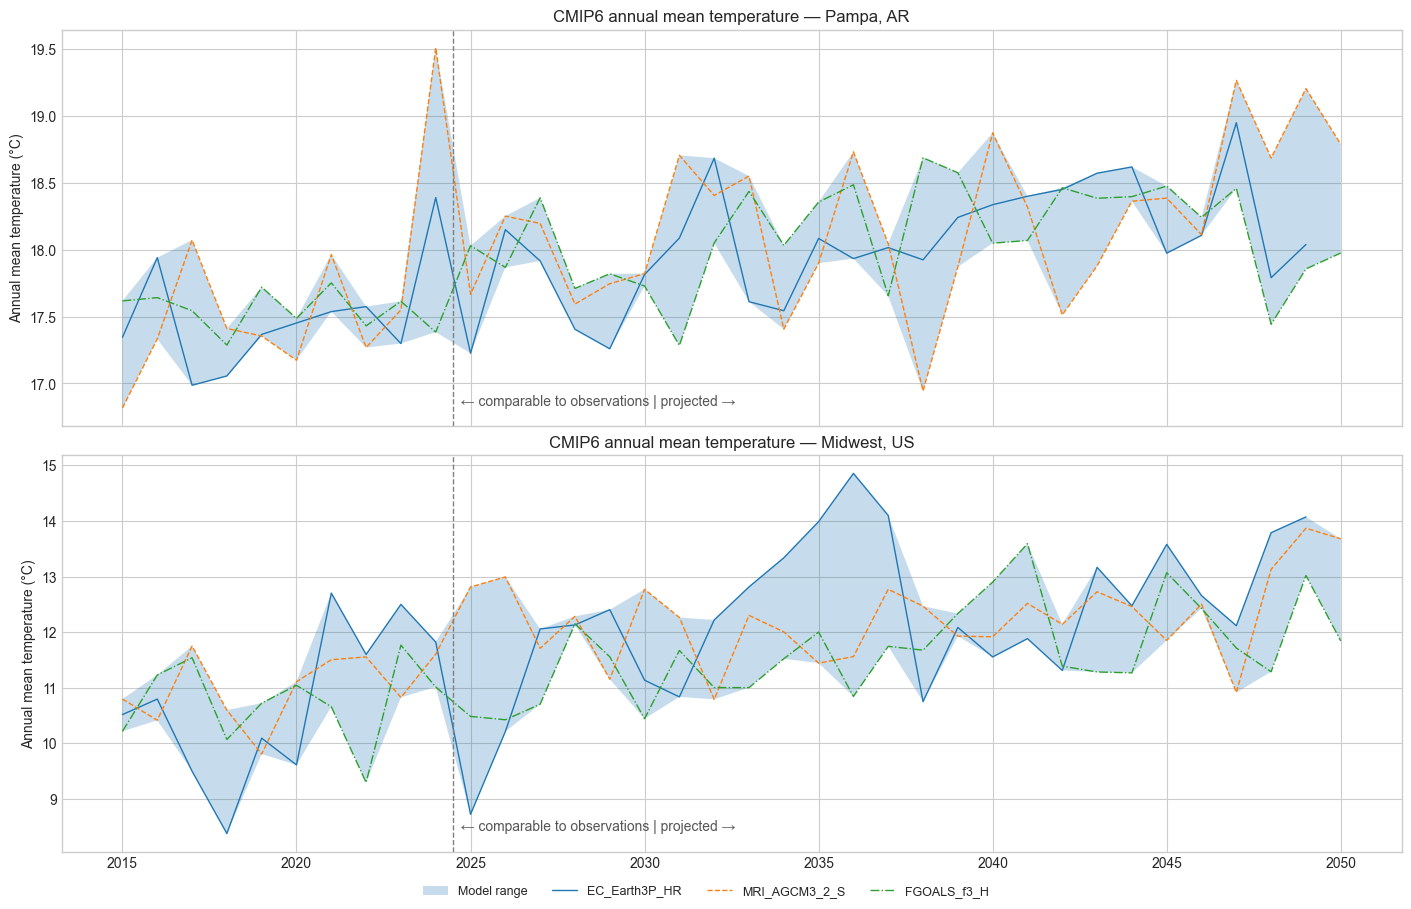

In [10]:
temperature = pd.concat(
    {site: annual_mean_temperature(df) for site, df in proj.items()}, axis=1, names=["site"]
)
plot_model_spread(
    temperature, "Annual mean temperature (°C)", "CMIP6 annual mean temperature", divider_year=2024.5
);

**Result**

- All three models warm at both sites. The Midwest warms more than twice as fast as Pampa (numbers in §4).
- The band stays wide during the whole period.
- No single year is a prediction: year-to-year variation is internal model variability.
- `EC_Earth3P_HR`'s line ends in 2049 (§2).

> **Structural uncertainty** — disagreement between equally defensible models under the same scenario. The band's width shows it.

### 3.2 Precipitation Spread

**Question**

Do the models agree on precipitation?

**Expectation**

- The *amount* of moisture in the air is thermodynamically constrained: warmer air holds about 7% more water vapour per °C, the Clausius–Clapeyron relation.
- *Where and when* that moisture falls depends on atmospheric circulation, and circulation is what each model resolves differently.
- So one would expect more disagreement than for temperature.

**What is compared**

- Annual totals, cleaned with §2's `annual_precipitation()`. Same kind of figure.

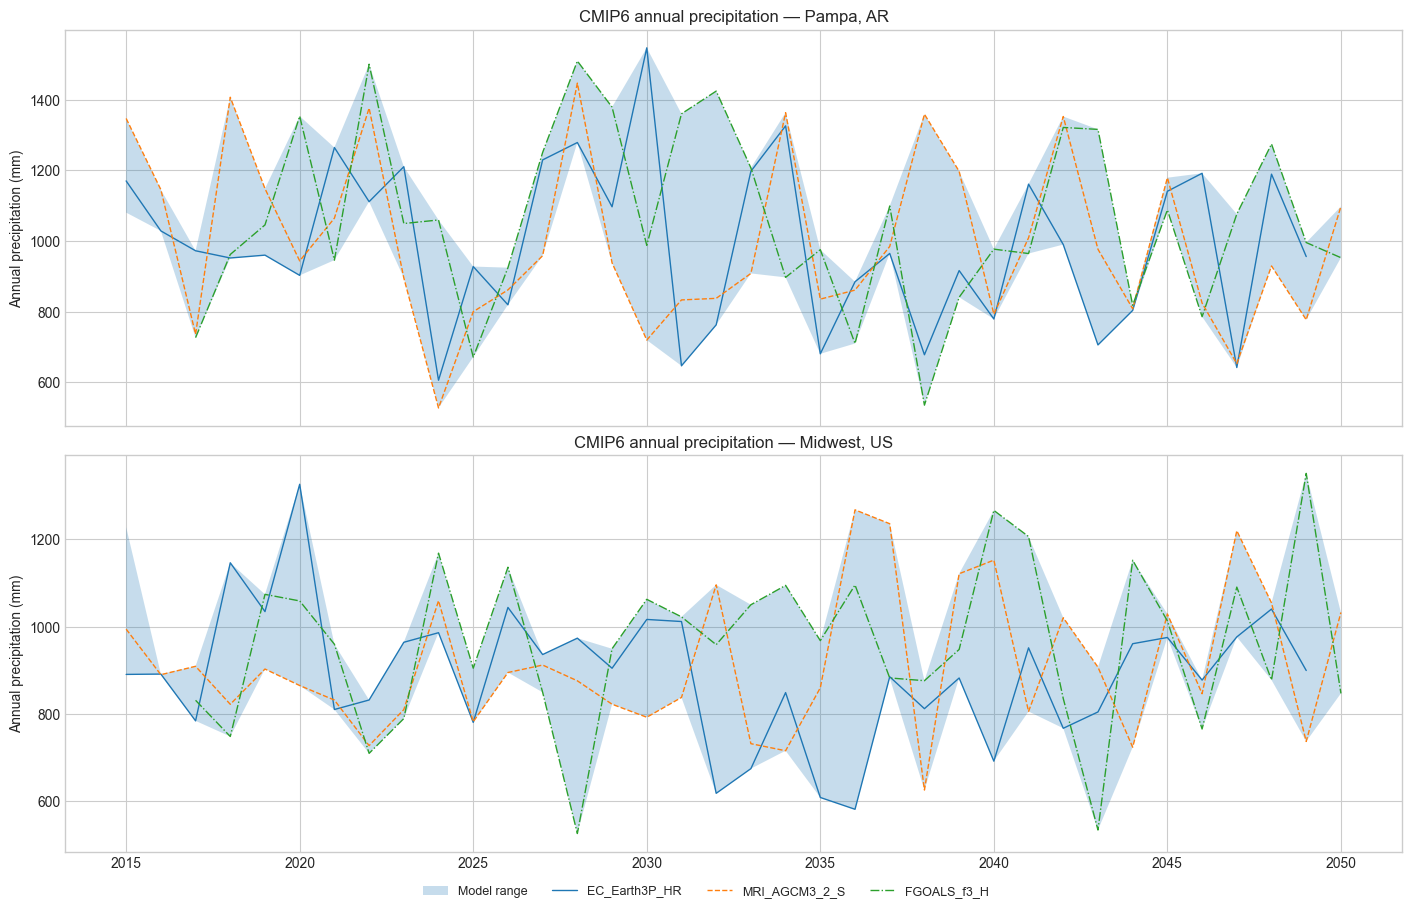

In [11]:
precipitation = pd.concat(
    {site: annual_precipitation(df) for site, df in proj.items()}, axis=1, names=["site"]
)
plot_model_spread(precipitation, "Annual precipitation (mm)", "CMIP6 annual precipitation");

**Result**

- The ranges stay wide and overlap during the whole period; no common trend is visible.
- The two §2 gaps appear as gaps in the lines, not as false values: `EC_Earth3P_HR` ends in 2049 and `FGOALS_f3_H`'s 2016 is masked. Unmasked, both would plot as drops to zero.
- §4 measures the disagreement.

## 4. Quantifying Disagreement

**Question**

How large is the disagreement between models, compared with the change itself?

**What is compared**

- Two decades per model and site: 2015–2024 and 2041–2050.
- Model columns: late mean minus early mean. This change is the signal.
- `mean`: the ensemble-mean change. `spread`: maximum minus minimum across models, the structural disagreement.
- When the spread is comparable to the mean change, no single model's number should be quoted alone.

**Temperature (°C)**

In [12]:
pd.DataFrame({site: decadal_change(temperature[site]) for site in SITES}).T

,EC_Earth3P_HR,MRI_AGCM3_2_S,FGOALS_f3_H,mean,spread
"Pampa, AR",0.8,0.8,0.6,0.7,0.2
"Midwest, US",2.0,1.6,1.3,1.6,0.7


**Result**

- Pampa: +0.6 to +0.8 °C. The spread (0.2 °C) is under a third of the ensemble-mean warming (0.7 °C).
- Midwest: +1.3 to +2.0 °C. The spread (0.7 °C) is over 40% of the ensemble-mean warming (1.6 °C).
- The sign is robust; the magnitude is not.

**Precipitation (mm/yr), cleaned totals from §2**

In [13]:
pd.DataFrame({site: decadal_change(precipitation[site]) for site in SITES}).T

,EC_Earth3P_HR,MRI_AGCM3_2_S,FGOALS_f3_H,mean,spread
"Pampa, AR",-42.2,-98.4,-21.0,-53.9,77.4
"Midwest, US",-49.6,56.5,15.4,7.4,106.1


**Result**

- Pampa: −21.0 to −98.4 mm/yr. All three models get drier, but the spread (77.4) is larger than the mean change (−53.9).
- Midwest: −49.6 to +56.5 mm/yr. The models disagree on the sign.

**The same table on uncleaned totals** (no plausibility floor; an empty year counts as 0 mm)

In [14]:
pd.DataFrame(
    {
        site: decadal_change(annual_precipitation(df, min_valid_days=0, floor_mm=None))
        for site, df in proj.items()
    }
).T

,EC_Earth3P_HR,MRI_AGCM3_2_S,FGOALS_f3_H,mean,spread
"Pampa, AR",-139.8,-98.4,71.0,-55.7,210.8
"Midwest, US",-141.3,56.5,107.4,7.5,248.7


**Result**

- Pampa, `FGOALS_f3_H`: +71 instead of −21. Its zero-filled 2016 lowers the early decade.
- Pampa, `EC_Earth3P_HR`: −140 instead of −42. Its empty 2050 counts as 0 mm and lowers the late decade.
- On uncleaned data, the models would disagree on the sign at Pampa too.

**Conclusions**

- Two data-quality fixes (§2) changed a qualitative conclusion, not only a number.
- Caveat: `EC_Earth3P_HR`'s late decade is 2041–2049.

## 5. Hindcast: Models Compared with the Recent Past

**Question**

Do the models reproduce the temperature of a period that has already happened (2015–2024)?

> **Hindcast** — a model run over a past period, so that its output can be compared with the historical record.

**Reference**

ERA5-Land, a reanalysis with a resolution of about 10 km.

**What is compared**

- Only the mean temperature of the period.
- Individual years are not expected to match: these model runs do not start from observed conditions.

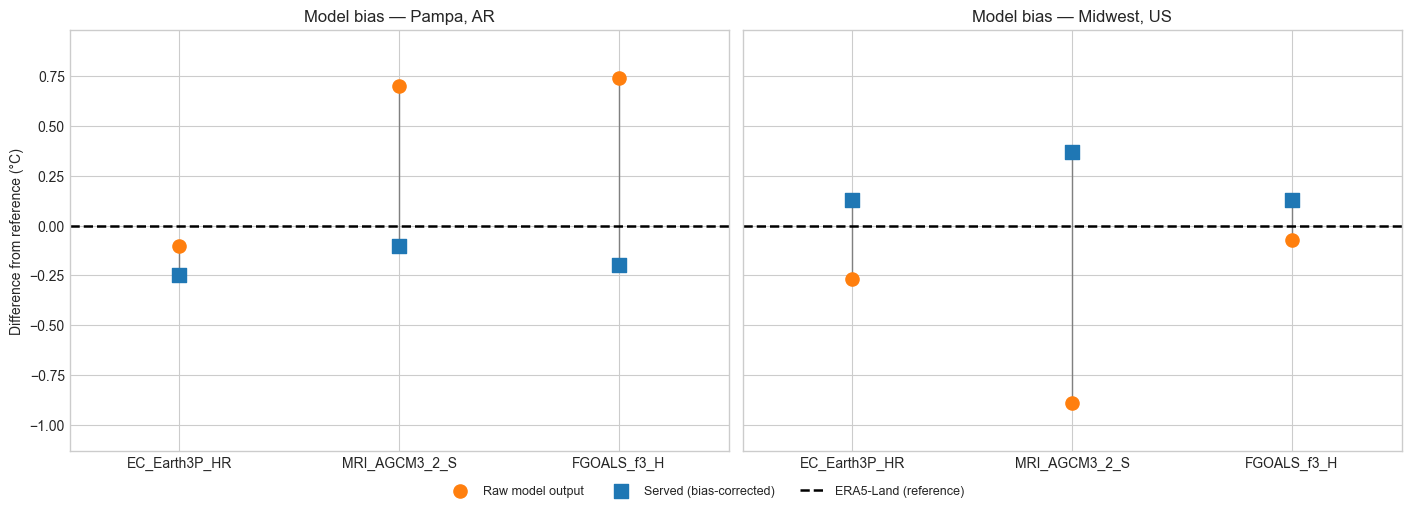

In [15]:
hindcast = {site: hindcast_annual(loc) for site, loc in SITES.items()}
levels = pd.concat({site: mean_levels(annual) for site, annual in hindcast.items()}, names=["site"])
plot_bias(levels);

**Result**

- Raw model output: up to 0.9 °C from the reference, and the models do not agree on the direction.
- Served data: within 0.4 °C of the reference for every model.

**Reason**

- Open-Meteo corrects each model towards ERA5-Land before serving it ([documentation](https://open-meteo.com/en/docs/climate-api)).
- The close agreement is a result of this correction. It is not a measure of model quality.

> **Bias** — a systematic difference between a model and a reference.

> **Bias correction** — an adjustment that removes this difference.

In [16]:
levels

raw  served  reference  raw − ref  served − ref
site        model                                                           
Pampa, AR   EC_Earth3P_HR  17.64   17.49      17.74      -0.10         -0.25
            MRI_AGCM3_2_S  18.45   17.64      17.74       0.70         -0.10
            FGOALS_f3_H    18.49   17.55      17.74       0.74         -0.20
Midwest, US EC_Earth3P_HR  10.35   10.75      10.62      -0.27          0.13
            MRI_AGCM3_2_S   9.73   10.99      10.62      -0.89          0.37
            FGOALS_f3_H    10.55   10.75      10.62      -0.07          0.13

**Values**

- `raw`, `served` and `reference`: mean temperature for 2015–2024, in °C.
- `raw − ref` and `served − ref`: difference from the reference.

In [17]:
inter_model_spread(levels)

,raw,served
site,,
"Pampa, AR",0.85,0.15
"Midwest, US",0.82,0.24


**Result**

- Before correction, the models differ from each other by about 0.8 °C.
- After correction, by about 0.2 °C.

**Conclusions**

- The served data hides most of the disagreement between models on temperature *levels*.
- It does not hide the disagreement on temperature *change* (§4). According to Open-Meteo, the correction does not affect the climate change signal.
- Indicators based on absolute thresholds (frost, heat stress) can use the served data. The correction is made by the provider and assumes that each model's bias stays constant in the future.

## 6. Findings & Limitations

### Findings

- **Multi-model parsing works end to end** — one request per site returns all three models (§1).
- **Each model has its own gaps, and none raises an error** — `EC_Earth3P_HR` ends in 2049; `FGOALS_f3_H`'s 2016 is zero on 350 of 366 days at both sites; soil moisture is empty for 2 of 3 models (§2).
- **Warming is robust; precipitation is not** — the temperature spread is under a third (Pampa) to over 40% (Midwest) of the ensemble-mean warming; precipitation change differs in sign at the Midwest (about −50 to +57 mm/yr) (§4).
- **Data quality changes conclusions** — on uncleaned data the models disagree on the sign at Pampa too (§4).
- **Agreement with reanalysis comes from the provider's bias correction** — raw output is −0.89 to +0.74 °C from ERA5-Land, served data −0.25 to +0.37 °C (2015–2024, §5).

### Limitations

- **One downscaling chain and one scenario** (high-emission, RCP8.5-like): the true structural uncertainty is wider.
- **Mixed experiment designs** — atmosphere-only and coupled runs are mixed, and Open-Meteo does not state which experiment it serves. The range is not a clean structural spread (details in the quality report).
- **Three models are a small sample** — the band is a lower bound on the uncertainty, not a confidence interval.
- **Regional averages only** — served at ~10 km, from native grids of ~20–50 km.
- **Annual means hide extremes** — heat waves, frosts and dry spells need daily indicators.
- **No additional bias correction applied** — the provider's correction assumes that each model's bias stays stable in the future. This is not tested here.

### Decision Gate

**Decision: risk-indicator prototyping must consume the ensemble *range*, never a single model's trajectory.**

- Why: warming is robust, precipitation is not, and the agreement in levels comes mostly from bias correction (§5).
- Next: prototype risk indicators that carry the model range end to end (building on notebook 01's water balance), and extend the quality assessment to Punjab and Central Kenya.

---

*The canonical quality record lives in [`docs/data-quality-report.md`](../docs/data-quality-report.md). Previous chapter: [`01-open-meteo-exploration.ipynb`](01-open-meteo-exploration.ipynb).*